In [1]:
import pathlib
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
from matplotlib import gridspec
import pandas as pd
import pingouin as pg
import seaborn as sns


import TwoPUtils as tpu
import STX3KO_analyses as stx

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42


%matplotlib inline

%load_ext autoreload
%autoreload 2
 

In [ ]:
# for day in range(6):
#     print(day)
#     sess = stx.utilities.load_vr_day('SparseKO_11', day, verbose = False, pkldir = '/mnt/BigDisk/YMaze_VR_Pkls/')
#     sess.novel_arm = -1
#     sess._abc_impl = None
#     # sess._abc = None
#     tpu.sess.save_session(sess,'/mnt/BigDisk/YMaze_VR_Pkls')


0
1
2
3
4
5


In [3]:
figdir = pathlib.Path('/mnt/BigDisk/fig_scratch/stx3/figS3_licks')
figdir.mkdir(exist_ok=True, parents=True)

In [4]:
rows = []
x = np.arange(-10,3)
for (cond, mice) in zip(('ctrl', 'ko', 'sparse'), (ctrl_mice, ko_mice, sparse_mice)):
    for day in range(6):
        print(day)
        for mouse in mice:
            if mouse=='SparseKO_09' and day==2:
                continue
            print(mouse)
            sess = stx.utilities.load_vr_day(mouse, day, trial_mat_keys = ('nonconsum_licks','licks_sum'),verbose = False, pkldir = '/mnt/BigDisk/YMaze_VR_Pkls/')

            bin_edges = sess.trial_matrices['bin_edges']
            right_rzone_front = np.argwhere((sess.rzone_late['tfront']<=bin_edges[1:])*(sess.rzone_late['tfront']>=bin_edges[:-1]))[0][0]
            left_rzone_front = np.argwhere((sess.rzone_early['tfront']<=bin_edges[1:])*(sess.rzone_early['tfront']>=bin_edges[:-1]))[0][0]

            if sess.novel_arm==-1:
                rzone_nov = left_rzone_front
                rzone_fam = right_rzone_front
            else:
                rzone_nov = right_rzone_front
                rzone_fam = left_rzone_front

            for ttype in ('fam', 'nov'):
                
                if ttype == 'nov':
                    trial_mask = sess.trial_info["LR"] == sess.novel_arm
                    rzone = rzone_nov
                else:
                    trial_mask = sess.trial_info["LR"] != sess.novel_arm
                    rzone = rzone_fam

                plot_vec = np.zeros([140,])*np.nan
                print(ttype, trial_mask.sum())
                
                licks = sess.trial_matrices['licks_sum'][trial_mask,:]
                rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))
                rzone_lick_plot_vec = np.nansum(licks[:,rzone-5:rzone+1], axis=1)/(np.nansum(licks,axis=1)+1E-3)
                plot_vec[:rzone_lick_plot_vec.shape[0]] = rzone_lick_plot_vec

                rows.append({'cond': cond,
                             'mouse': mouse,
                             'day': day,
                             'ttype': ttype,
                             'rzone_licks': rzone_licks,
                             'rzone_licks_plot_vec': plot_vec,
                             })
df = pd.DataFrame(rows)
                
                

0
4467331.1
fam 120
nov 19
4467331.2
fam 121
nov 19
4467332.1
fam 118
nov 20
4467332.2
fam 81
nov 19
4467333.1
fam 121
nov 19
mCherry6
fam 120
nov 20
mCherry7
fam 120
nov 20
mCherry8
fam 122
nov 18
mCherry9
fam 119
nov 21
1
4467331.1
fam 119
nov 21
4467331.2
fam 121
nov 19
4467332.1
fam 112
nov 16
4467332.2
fam 118
nov 18
4467333.1
fam 121
nov 19
mCherry6
fam 120
nov 20
mCherry7
fam 120
nov 20
mCherry8
fam 121
nov 19
mCherry9
fam 121
nov 19
2
4467331.1
fam 119
nov 21
4467331.2
fam 120
nov 20
4467332.1
fam 119
nov 20
4467332.2
fam 120
nov 20
4467333.1
fam 119
nov 21
mCherry6
fam 122
nov 18
mCherry7
fam 120
nov 20
mCherry8


/tmp/ipykernel_474529/1402416721.py:36: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))
/tmp/ipykernel_474529/1402416721.py:36: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))
/tmp/ipykernel_474529/1402416721.py:36: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))


fam 121
nov 19
mCherry9
fam 120
nov 20
3
4467331.1
fam 121
nov 19
4467331.2
fam 121
nov 19
4467332.1
fam 120
nov 20
4467332.2
fam 121
nov 19
4467333.1
fam 121
nov 19
mCherry6
fam 121
nov 19
mCherry7
fam 120
nov 20
mCherry8
fam 120
nov 18
mCherry9
fam 120
nov 20
4
4467331.1
fam 118
nov 21
4467331.2
fam 121
nov 19
4467332.1
fam 120
nov 20
4467332.2
fam 120
nov 19
4467333.1
fam 119
nov 21
mCherry6
fam 122
nov 18
mCherry7
fam 121
nov 19
mCherry8
fam 122
nov 18
mCherry9
fam 120
nov 20
5
4467331.1
fam 64
nov 76
4467331.2
fam 70
nov 70
4467332.1
fam 63
nov 77
4467332.2
fam 75
nov 64
4467333.1
fam 70
nov 70
mCherry6
fam 83
nov 57
mCherry7
fam 75
nov 65
mCherry8
fam 76
nov 64
mCherry9
fam 59
nov 81
0
4467975.1


/tmp/ipykernel_474529/1402416721.py:36: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))
/tmp/ipykernel_474529/1402416721.py:36: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))
/tmp/ipykernel_474529/1402416721.py:36: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))
/tmp/ipykernel_474529/1402416721.py:36: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))
/tmp/ipykernel_474529/1402416721.py:36: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))
/tmp/ipykernel_474529/1402416721.py:36: RuntimeWarning: inva

fam 122
nov 22
4467975.2
fam 121
nov 18
4467975.3
fam 85
nov 17
4467975.4
fam 108
nov 17
4467975.5
fam 48
nov 7
Cre7
fam 120
nov 19
Cre9
fam 116
nov 18
1
4467975.1
fam 108
nov 16
4467975.2
fam 109
nov 15
4467975.3
fam 81
nov 15
4467975.4
fam 102
nov 18
4467975.5
fam 58
nov 6
Cre7
fam 108
nov 19
Cre9
fam 117
nov 16
2
4467975.1
fam 116
nov 20
4467975.2
fam 100
nov 9
4467975.3
fam 70
nov 7
4467975.4
fam 103
nov 19
4467975.5
fam 38
nov 7
Cre7
fam 110
nov 21
Cre9
fam 104
nov 10
3
4467975.1
fam 119
nov 20
4467975.2
fam 77
nov 7
4467975.3
fam 78
nov 14
4467975.4
fam 119
nov 17
4467975.5
fam 49
nov 10
Cre7
fam 115
nov 21
Cre9
fam 103
nov 13
4
4467975.1


/tmp/ipykernel_474529/1402416721.py:36: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))
/tmp/ipykernel_474529/1402416721.py:36: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))
/tmp/ipykernel_474529/1402416721.py:36: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))
/tmp/ipykernel_474529/1402416721.py:36: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))
/tmp/ipykernel_474529/1402416721.py:36: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))
/tmp/ipykernel_474529/1402416721.py:36: RuntimeWarning: inva

fam 119
nov 21
4467975.2
fam 102
nov 15
4467975.3
fam 82
nov 11
4467975.4
fam 107
nov 18
4467975.5
fam 32
nov 6
Cre7
fam 51
nov 7
Cre9
fam 58
nov 6
5
4467975.1
fam 71
nov 68
4467975.2
fam 71
nov 62
4467975.3
fam 40
nov 38
4467975.4
fam 56
nov 55
4467975.5
fam 36
nov 38
Cre7
fam 50
nov 58
Cre9
fam 53
nov 53
0
SparseKO_02
fam 56
nov 10
SparseKO_06
fam 115
nov 17
SparseKO_08
fam 120
nov 20
SparseKO_10
fam 109
nov 18
SparseKO_11
fam 19
nov 91
SparseKO_13
fam 121
nov 19
SparseKO_09
fam 88
nov 8
1
SparseKO_02
fam 79
nov 14
SparseKO_06
fam 105
nov 17
SparseKO_08
fam 99
nov 18
SparseKO_10
fam 118
nov 19
SparseKO_11
fam 10
nov 34
SparseKO_13
fam 122
nov 18
SparseKO_09
fam 94
nov 16
2
SparseKO_02


/tmp/ipykernel_474529/1402416721.py:36: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))
/tmp/ipykernel_474529/1402416721.py:36: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))
/tmp/ipykernel_474529/1402416721.py:36: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))
/tmp/ipykernel_474529/1402416721.py:36: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))
/tmp/ipykernel_474529/1402416721.py:36: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))
/tmp/ipykernel_474529/1402416721.py:36: RuntimeWarning: inva

fam 89
nov 16
SparseKO_06
fam 107
nov 18
SparseKO_08
fam 120
nov 20
SparseKO_10
fam 121
nov 19
SparseKO_11
fam 11
nov 62
SparseKO_13
fam 120
nov 20
3
SparseKO_02
fam 96
nov 17
SparseKO_06
fam 116
nov 19
SparseKO_08
fam 119
nov 21
SparseKO_10
fam 119
nov 18
SparseKO_11
fam 10
nov 53
SparseKO_13
fam 120
nov 20
SparseKO_09
fam 120
nov 20
4
SparseKO_02
fam 95
nov 14
SparseKO_06
fam 101
nov 18
SparseKO_08
fam 120
nov 20
SparseKO_10
fam 117
nov 17
SparseKO_11
fam 12
nov 78
SparseKO_13
fam 121
nov 19
SparseKO_09
fam 120
nov 20
5
SparseKO_02
fam 49
nov 56
SparseKO_06
fam 67
nov 67
SparseKO_08
fam 64
nov 76
SparseKO_10
fam 61
nov 58
SparseKO_11
fam 32
nov 30
SparseKO_13
fam 69
nov 71
SparseKO_09
fam 74
nov 66


/tmp/ipykernel_474529/1402416721.py:36: RuntimeWarning: invalid value encountered in divide
  rzone_licks = np.nanmean(np.nansum(licks[:,rzone-5:rzone+1], axis=1)/np.nansum(licks,axis=1))


/tmp/ipykernel_474307/2546476860.py:11: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(lick_acc,axis=0)


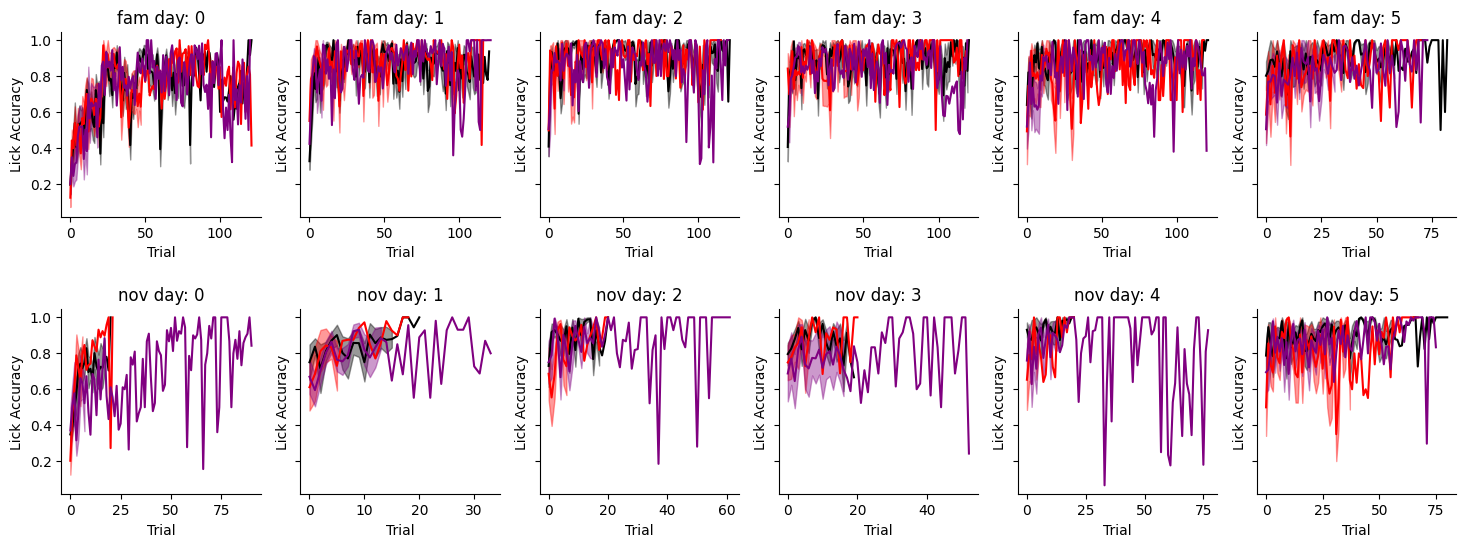

In [12]:
days = np.arange(6)
fig, ax = plt.subplots(2,6, figsize=[18,6], sharey=True)
fig.subplots_adjust(hspace=.5)
for  cond, mice, color in zip(('ctrl', 'ko', 'sparse'), (ctrl_mice, ko_mice, sparse_mice), ('black', 'red', 'purple')): 
    for i, ttype in enumerate(('fam', 'nov')):
        for day in days:
            mask = (df['cond']==cond) * (df['day']==day) * (df['ttype']==ttype)

            # print(np.vstack(df.loc[mask, 'rzone_licks_plot_vec'].values).shape)
            lick_acc = np.vstack(df.loc[mask, 'rzone_licks_plot_vec'].values)
            mu = np.nanmean(lick_acc,axis=0)
            sem = sp.stats.sem(lick_acc,axis=0)
            x = np.arange(mu.shape[0])
            ax[i,day].plot(x, mu, color=color)
            ax[i,day].fill_between(x, mu-sem, mu+sem, alpha=.4, color=color)

            ax[i,day].set_title(f'{ttype} day: {day}')

for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.set_xlabel('Trial')
    a.set_ylabel('Lick Accuracy')

fig.savefig(figdir / "lick_accuracy_v_days.pdf")

In [17]:
# 
from STX3KO_analyses import utilities as u

# sess = u.load_vr_day(sparse_mice[0], 0 , pkldir = '/mnt/BigDisk/YMaze_VR_Pkls/')
sess = u.load_vr_day(ko_mice[0], 1 , pkldir = '/mnt/BigDisk/YMaze_VR_Pkls/')
# sess = u.load_single_day(ctrl_mice[0], 0)

{'date': '29_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 2}


In [18]:
sess.timeseries['licks'].shape

(1, 100114)

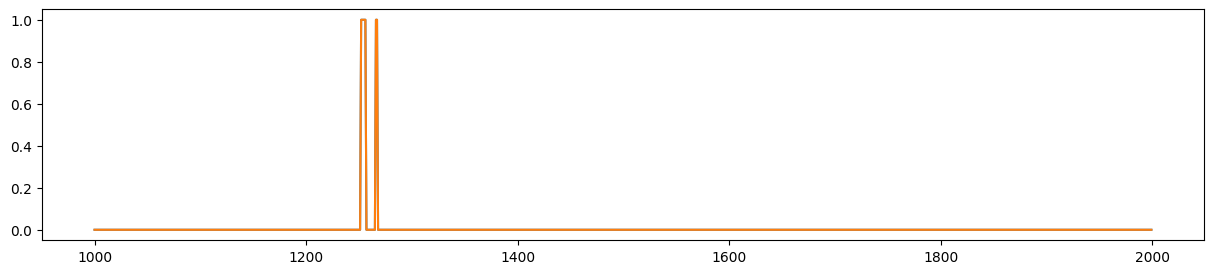

In [23]:
fig, ax = plt.subplots(figsize=[15,3])
x = np.arange(1000,2000)
ax.plot(x,sess.vr_data['lick'].iloc[x[0]:x[-1]+1])
ax.plot(x,sess.timeseries['licks'][0,x[0]:x[-1]+1])

In [110]:
mu = np.nanmean(sess.trial_matrices['licks_sum'][sess.trial_info['LR']!=sess.novel_arm, :], axis=0)

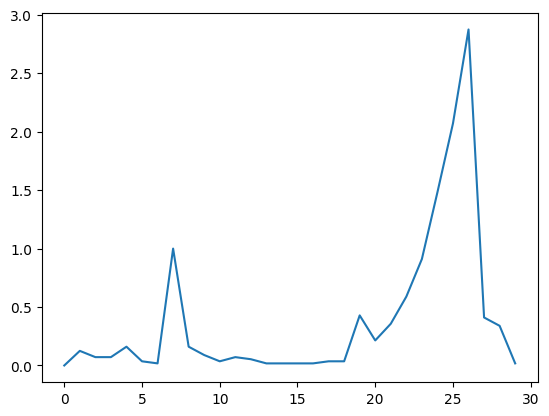

In [111]:
fig, ax = plt.subplots()
ax.plot(mu)